# Attribute-Based Emergence Analysis  
### Using Layerwise Linear Probes on ResNet-50  
**Dataset:** CUB-200-2011  
**Goal:** Understand when different semantic properties become decodable inside a CNN

---

## What We Will Measure

We define:

**Emergence depth (sharp-rise)**:  
> The layer ℓ where the probe accuracy curve has its **largest jump** (argmax of Δ accuracy between consecutive layers).  
> (We return the *later* layer, i.e. the layer where the jump is realized.)

This compresses an accuracy-vs-depth curve into one meaningful number, without using an arbitrary threshold like 0.9×max.


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))


In [2]:
# CELL 1 — Imports and setup

import sys, os
sys.path.append(os.path.abspath(".."))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

# ---- Paths (baseline + cbm) ----
BASELINE_JSON = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_JSON      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

assert BASELINE_JSON.exists(), f"Missing {BASELINE_JSON}"
assert CBM_JSON.exists(), f"Missing {CBM_JSON}"

# ---- Canonical layer order ----
LAYERS_ORDERED = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]
layer_to_idx = {l: i for i, l in enumerate(LAYERS_ORDERED)}


In [3]:
# CELL 2 — Load JSON results (baseline + cbm into df_all)

def load_probe_json(path: Path, model_name: str) -> pd.DataFrame:
    with open(path, "r") as f:
        data = json.load(f)  # list[dict]
    df = pd.DataFrame(data)
    df["model"] = model_name
    return df

df_all = pd.concat(
    [load_probe_json(BASELINE_JSON, "baseline"),
     load_probe_json(CBM_JSON, "cbm")],
    ignore_index=True
)

needed_cols = {"layer", "target_type", "target_name", "best_val_acc", "group", "model"}
missing = needed_cols - set(df_all.columns)
assert not missing, f"Missing required columns in JSON: {missing}"

df_all = df_all[df_all["layer"].isin(LAYERS_ORDERED)].copy()
df_all["layer_idx"] = df_all["layer"].map(layer_to_idx)

print("Loaded df_all:", df_all.shape)
print("Models:", df_all["model"].unique())
print("Target types:", df_all["target_type"].unique())

df_all.head()


Loaded df_all: (1320, 10)
Models: ['baseline' 'cbm']
Target types: ['subclass' 'attribute']


,layer,target_type,target_name,group,train_acc,val_acc,best_val_acc,column,model,layer_idx
0,conv1,subclass,species,species,0.020521,0.015533,0.016224,NaN,baseline,0
1,layer1,subclass,species,species,0.049383,0.039178,0.040387,NaN,baseline,1
2,layer2,subclass,species,species,0.100601,0.055920,0.060580,NaN,baseline,2
3,layer3,subclass,species,species,0.282282,0.138764,0.138764,NaN,baseline,3
4,layer4,subclass,species,species,1.000000,0.726269,0.727132,NaN,baseline,4


In [4]:
# CELL 3 — Compute emergence depth (sharp-rise metric)

def get_curve(df: pd.DataFrame, target_type: str, target_name: str, model: str) -> pd.Series:
    sub = df[(df["model"] == model) &
             (df["target_type"] == target_type) &
             (df["target_name"] == target_name)].copy()
    if sub.empty:
        return pd.Series(index=LAYERS_ORDERED, dtype=float)

    # if duplicates exist, take max best_val_acc per layer
    sub = sub.groupby("layer", as_index=False)["best_val_acc"].max()
    sub["layer_idx"] = sub["layer"].map(layer_to_idx)
    sub = sub.sort_values("layer_idx")

    curve = pd.Series(sub["best_val_acc"].values, index=sub["layer"].values)
    curve = curve.reindex(LAYERS_ORDERED)  # fill missing with NaN
    return curve

def sharp_rise_layer(curve: pd.Series) -> str | None:
    vals = curve.values.astype(float)
    if np.all(np.isnan(vals)):
        return None

    # ffill/bfill so missing layers don't break diffs
    vals_ff = pd.Series(vals).ffill().bfill().values
    diffs = np.diff(vals_ff)  # length len(LAYERS_ORDERED)-1
    j = int(np.argmax(diffs))  # index of max jump
    return LAYERS_ORDERED[j + 1]  # later layer where jump is realized

# Build emerge_df for *all targets* (attributes + species), per model
records = []
targets = df_all[["target_type", "target_name", "group"]].drop_duplicates()

for _, row in targets.iterrows():
    ttype = row["target_type"]
    tname = row["target_name"]
    tgroup = row["group"]

    for model in ["baseline", "cbm"]:
        curve = get_curve(df_all, ttype, tname, model)
        if curve.empty or np.all(np.isnan(curve.values)):
            continue
        max_acc = float(np.nanmax(curve.values))
        em_layer = sharp_rise_layer(curve)
        records.append({
            "model": model,
            "target_type": ttype,
            "target_name": tname,
            "group": tgroup,
            "max_acc": max_acc,
            "emergence_layer": em_layer
        })

emerge_df = pd.DataFrame(records)
emerge_df["layer_idx"] = emerge_df["emergence_layer"].map(layer_to_idx)

print("Total targets measured (rows = target x model):", len(emerge_df))
emerge_df.head()


Total targets measured (rows = target x model): 220


,model,target_type,target_name,group,max_acc,emergence_layer,layer_idx
0,baseline,subclass,species,species,0.727822,layer4,4
1,cbm,subclass,species,species,0.623058,layer4,4
2,baseline,attribute,has_bill_shape::dagger,has_bill_shape,0.878668,layer4,4
3,cbm,attribute,has_bill_shape::dagger,has_bill_shape,0.884708,layer1,1
4,baseline,attribute,has_bill_shape::all-purpose,has_bill_shape,0.721263,layer4,4


In [5]:
# CELL 4 — Summary table by group (robust version)

# 1. Count how many targets per group
group_counts = (
    emerge_df.groupby("group")
    .size()
    .rename("num_attributes")
    .sort_values(ascending=False)
)

print("Number of groups:", group_counts.shape[0])
print("Top 15 groups by attribute count:")
display(group_counts.head(15))

# 2. Compute the most common emergence layer per group
group_mode_layer = (
    emerge_df.groupby("group")["emergence_layer"]
    .agg(lambda x: x.value_counts().index[0])  # most frequent emergence layer
    .rename("most_common_layer")
)

# 3. Combine counts + mode layer into a single summary table
summary = pd.concat([group_mode_layer, group_counts], axis=1).reset_index()

print("\nFull summary (unfiltered):")
display(summary.head(20))

# 4. OPTIONAL: apply a *looser* filter, e.g. ≥ 3 attributes
MIN_ATTRS = 3   # change to 5 if you want stricter, 1 if you want everything

summary_filtered = summary[summary["num_attributes"] >= MIN_ATTRS]

print(f"\nFiltered summary (groups with ≥ {MIN_ATTRS} attributes): "
      f"{summary_filtered.shape[0]} groups remain")

summary_filtered.sort_values(by="num_attributes", ascending=False).head(20)


Number of groups: 29
Top 15 groups by attribute count:


group
has_underparts_color    12
has_breast_color        12
has_primary_color       12
has_back_color          10
has_forehead_color      10
has_wing_color          10
has_upperparts_color    10
has_upper_tail_color    10
has_under_tail_color    10
has_throat_color        10
has_head_pattern        10
has_nape_color          10
has_crown_color         10
has_belly_color         10
has_breast_pattern       6
Name: num_attributes, dtype: int64


Full summary (unfiltered):


,group,most_common_layer,num_attributes
0,has_back_color,layer4,10
1,has_back_pattern,layer1,6
2,has_belly_color,layer4,10
3,has_belly_pattern,layer1,6
4,has_bill_color,layer1,6
5,has_bill_length,layer4,4
6,has_bill_shape,layer4,6
7,has_breast_color,layer4,12
8,has_breast_pattern,layer1,6
9,has_crown_color,layer4,10



Filtered summary (groups with ≥ 3 attributes): 26 groups remain


,group,most_common_layer,num_attributes
22,has_underparts_color,layer4,12
7,has_breast_color,layer4,12
15,has_primary_color,layer4,12
0,has_back_color,layer4,10
12,has_head_pattern,layer1,10
25,has_wing_color,layer4,10
24,has_upperparts_color,layer4,10
23,has_upper_tail_color,layer1,10
21,has_under_tail_color,layer1,10
20,has_throat_color,layer4,10


In [6]:
# CELL 5 — Map layer → numeric index for plotting

# species-only depth (pick baseline by default; change to cbm if you want)
species_depth = emerge_df[(emerge_df["group"] == "species") & (emerge_df["model"] == "baseline")]["layer_idx"].iloc[0]
species_depth


4

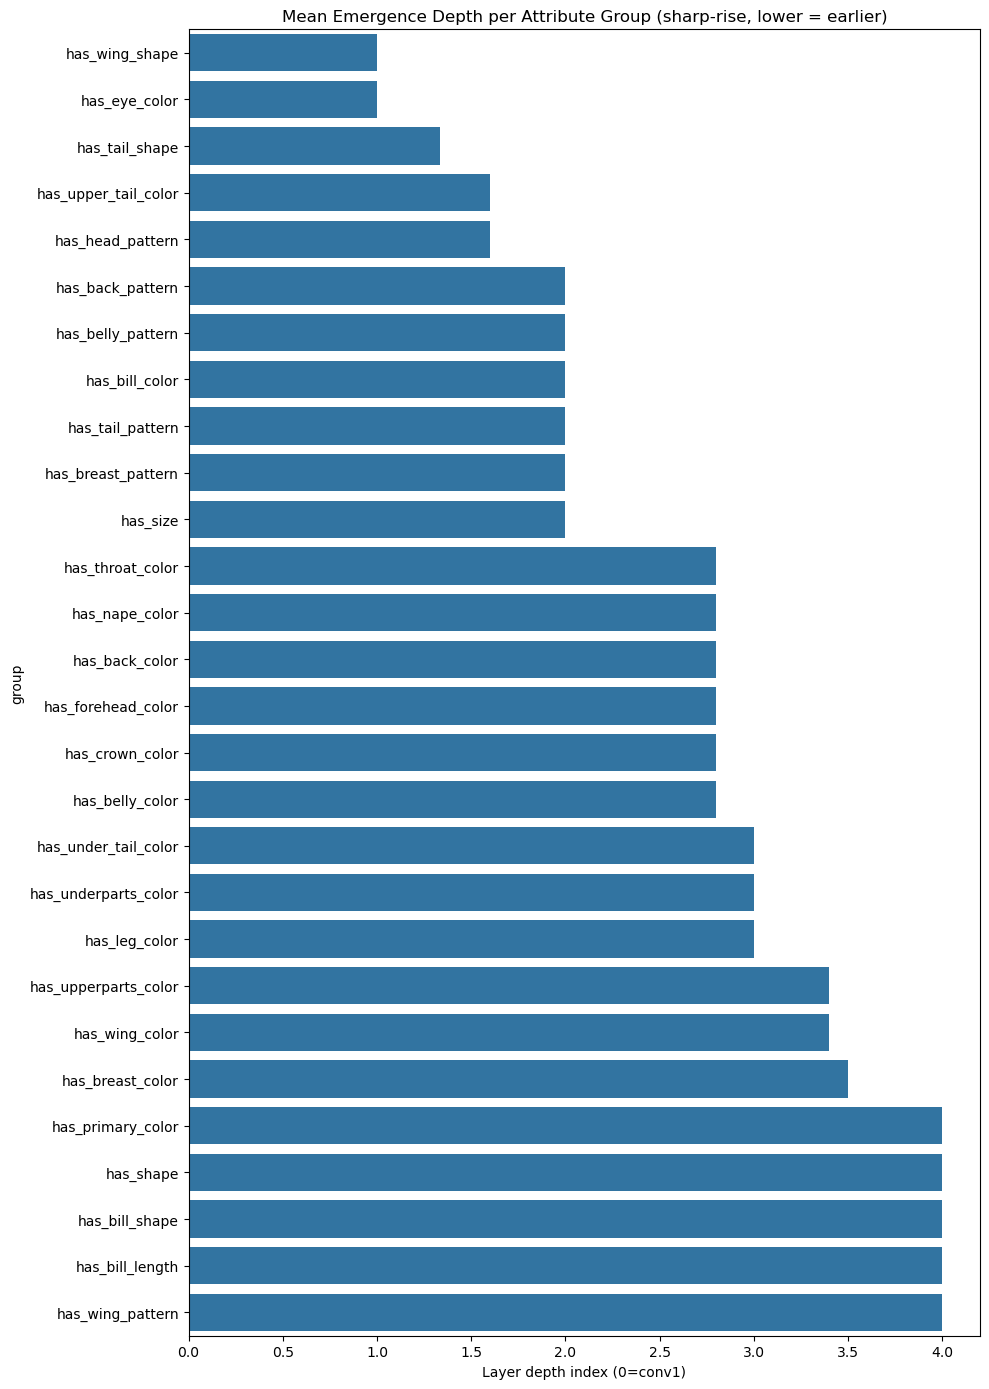

In [7]:
# CELL 6 — Barplot of mean emergent depth (sharp-rise)

# Use attributes only (exclude species) by default
tmp = emerge_df[(emerge_df["group"] != "species") & (emerge_df["target_type"] == "attribute")].copy()

# Example: plot baseline only; change to cbm if desired
tmp = tmp[tmp["model"] == "baseline"]

agg = tmp.groupby("group")["layer_idx"].mean().sort_values()

plt.figure(figsize=(10, 14))
sns.barplot(x=agg.values, y=agg.index)
plt.title("Mean Emergence Depth per Attribute Group (sharp-rise, lower = earlier)")
plt.xlabel("Layer depth index (0=conv1)")
plt.tight_layout()
plt.show()


In [8]:
# CELL 7 — Compare species vs attribute emergence (sharp-rise)

model = "baseline"  # or "cbm"

species_row = emerge_df[(emerge_df["group"] == "species") & (emerge_df["model"] == model)].iloc[0]
species_layer_idx = species_row["layer_idx"]

mean_attr = emerge_df[(emerge_df["group"] != "species") &
                      (emerge_df["target_type"] == "attribute") &
                      (emerge_df["model"] == model)]["layer_idx"].mean()

print("Model:", model)
print("Species emergence depth index:", species_layer_idx)
print("Mean attribute emergence depth index:", mean_attr)
print("\nDifference:", species_layer_idx - mean_attr)


Model: baseline
Species emergence depth index: 4
Mean attribute emergence depth index: 2.7522935779816513

Difference: 1.2477064220183487


In [9]:
attr_only = emerge_df[emerge_df["target_type"] == "attribute"].copy()

dist = (
    attr_only.groupby(["model", "emergence_layer"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["model", "count"], ascending=[True, False])
)
display(dist)

# Fraction of attributes whose sharp-rise emergence is each layer (per model)
frac = (
    attr_only.groupby(["model", "emergence_layer"]).size()
    / attr_only.groupby("model").size()
).rename("fraction").reset_index().sort_values(["model", "fraction"], ascending=[True, False])
display(frac)


,model,emergence_layer,count
3,baseline,layer4,62
1,baseline,layer1,45
0,baseline,avgpool,1
2,baseline,layer2,1
6,cbm,layer4,68
5,cbm,layer1,40
4,cbm,avgpool,1


,model,emergence_layer,fraction
3,baseline,layer4,0.568807
1,baseline,layer1,0.412844
0,baseline,avgpool,0.009174
2,baseline,layer2,0.009174
6,cbm,layer4,0.623853
5,cbm,layer1,0.366972
4,cbm,avgpool,0.009174


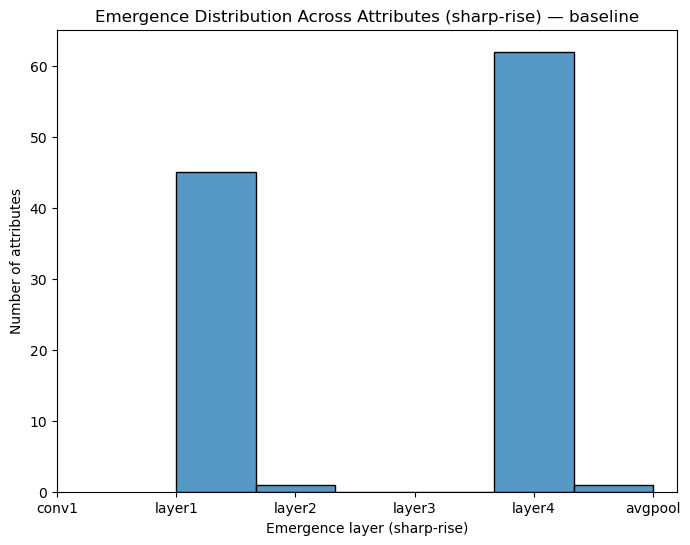

In [10]:
# CELL 8 — Distribution histogram (sharp-rise)

model = "baseline"  # or "cbm"
tmp = emerge_df[(emerge_df["target_type"] == "attribute") & (emerge_df["model"] == model)]

plt.figure(figsize=(8, 6))
sns.histplot(tmp["layer_idx"], bins=len(LAYERS_ORDERED), kde=False)
plt.xticks(range(len(LAYERS_ORDERED)), LAYERS_ORDERED)
plt.xlabel("Emergence layer (sharp-rise)")
plt.ylabel("Number of attributes")
plt.title(f"Emergence Distribution Across Attributes (sharp-rise) — {model}")
plt.show()


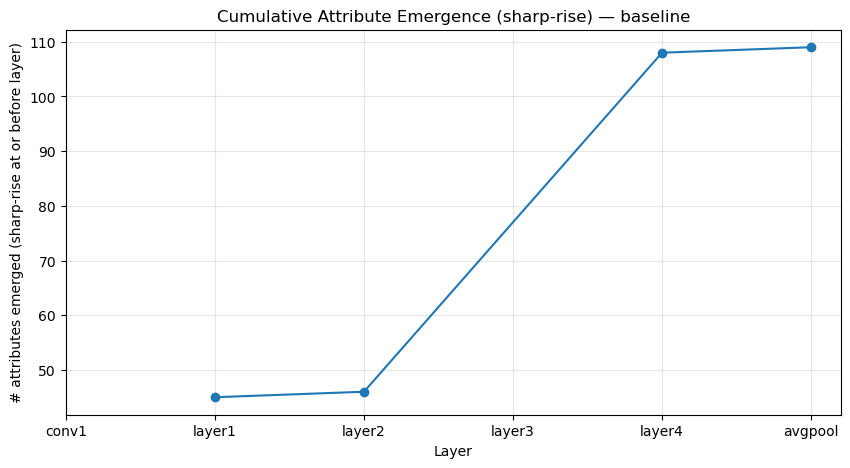

In [11]:
# CELL 9 — Cumulative emergence curve (sharp-rise)

model = "baseline"  # or "cbm"
tmp = emerge_df[(emerge_df["target_type"] == "attribute") & (emerge_df["model"] == model)]

layer_counts = tmp["layer_idx"].value_counts().sort_index()
cum_counts = layer_counts.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(cum_counts.index, cum_counts.values, marker="o")
plt.xticks(range(len(LAYERS_ORDERED)), LAYERS_ORDERED)
plt.ylabel("# attributes emerged (sharp-rise at or before layer)")
plt.xlabel("Layer")
plt.title(f"Cumulative Attribute Emergence (sharp-rise) — {model}")
plt.grid(True, alpha=0.3)
plt.show()


Attributes we will plot (exist in df): ['has_throat_color::black', 'has_back_color::black', 'has_shape::perching-like']


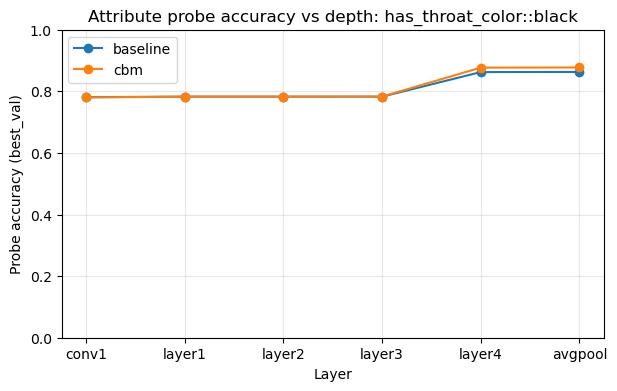

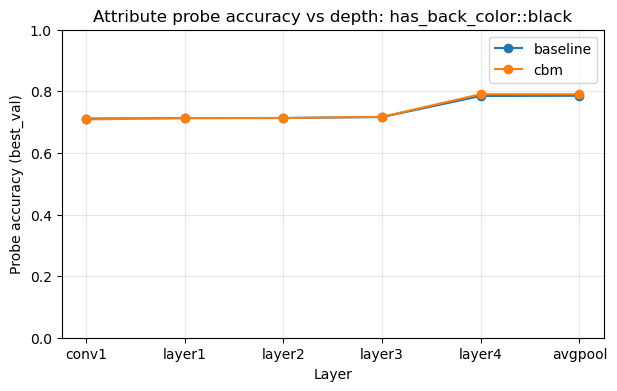

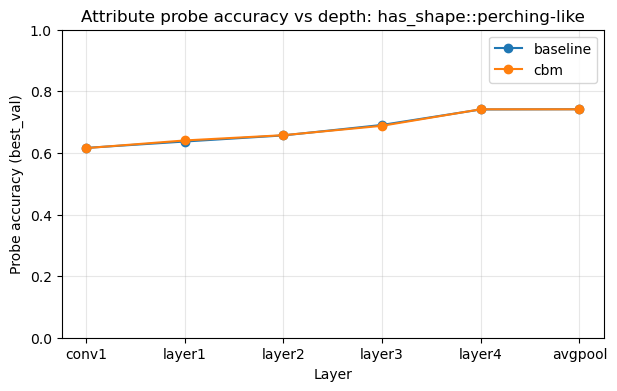

In [12]:
# CELL 10 — Attribute probe curves (baseline vs cbm), like your screenshot

def plot_curve(curve_baseline: pd.Series, curve_cbm: pd.Series, title: str):
    x = np.arange(len(LAYERS_ORDERED))
    plt.figure(figsize=(7, 4))
    plt.plot(x, curve_baseline.values, marker="o", label="baseline")
    plt.plot(x, curve_cbm.values, marker="o", label="cbm")
    plt.xticks(x, LAYERS_ORDERED, rotation=0)
    plt.ylim(0, 1.0)
    plt.xlabel("Layer")
    plt.ylabel("Probe accuracy (best_val)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

attrs_to_plot = [
    "has_throat_color::black",
    "has_back_color::black",
    "has_shape::perching-like"
]

existing_attrs = set(df_all.loc[df_all["target_type"] == "attribute", "target_name"].unique())
attrs_to_plot = [a for a in attrs_to_plot if a in existing_attrs]
print("Attributes we will plot (exist in df):", attrs_to_plot)

for a in attrs_to_plot:
    c0 = get_curve(df_all, "attribute", a, "baseline")
    c1 = get_curve(df_all, "attribute", a, "cbm")
    plot_curve(c0, c1, f"Attribute probe accuracy vs depth: {a}")


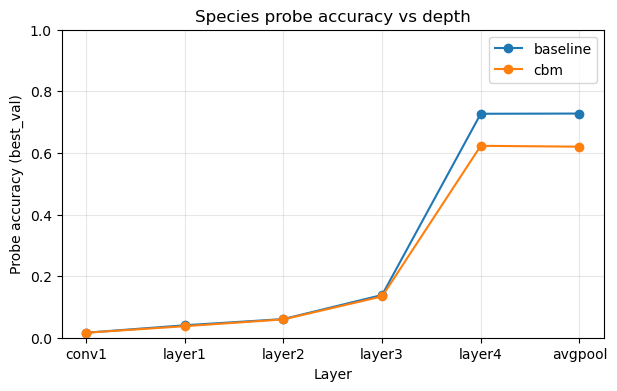

Auto-picked attributes to plot:
  - has_throat_color::yellow
  - has_size::small_(5_-_9_in)
  - has_underparts_color::white


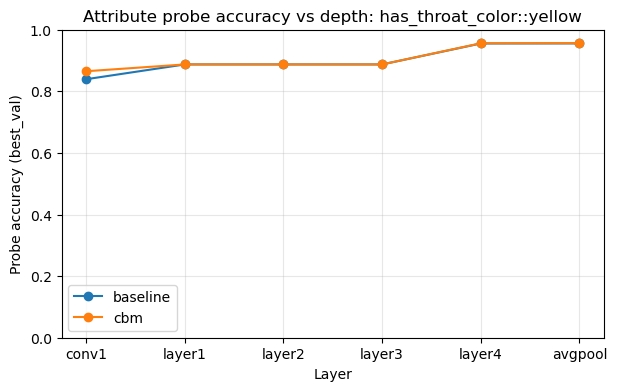

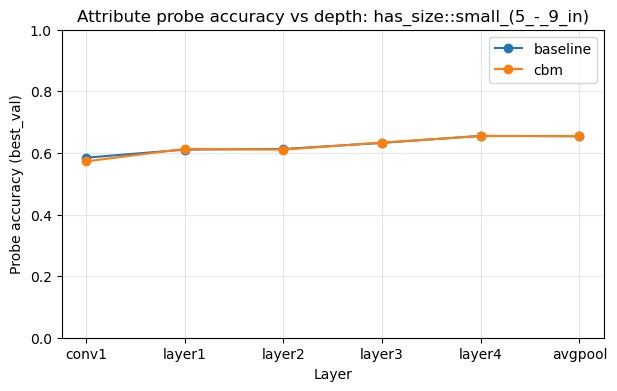

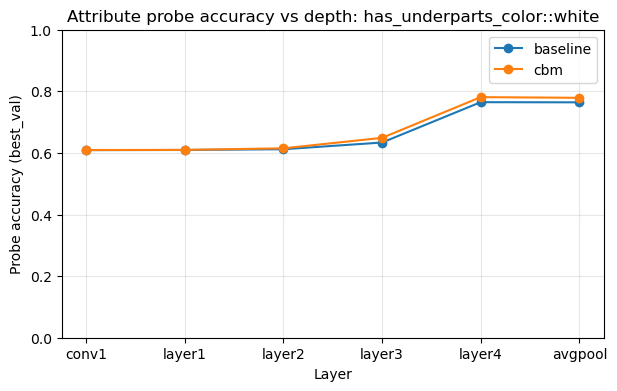

In [13]:
# CELL 12 — Auto-pick real attributes from df_all + plot species (baseline vs cbm)
# Uses your existing: LAYERS_ORDERED, df_all, get_curve(), plot_curve()

import numpy as np
import pandas as pd

# -----------------------------
# 0) Sanity checks
# -----------------------------
assert "df_all" in globals(), "df_all not found—run the earlier loading cell first."
assert "get_curve" in globals(), "get_curve not found—run the helper-function cell first."
assert "plot_curve" in globals(), "plot_curve not found—run the plotting helper cell first."

# -----------------------------
# 1) Plot species curve (baseline vs cbm) — exactly like attributes
# -----------------------------
species_name = "species"
curve_sp_base = get_curve(df_all, "subclass", species_name, "baseline")
curve_sp_cbm  = get_curve(df_all, "subclass", species_name, "cbm")
plot_curve(curve_sp_base, curve_sp_cbm, "Species probe accuracy vs depth")

# -----------------------------
# 2) Auto-select 3 real attributes from the dataset (no guessing names)
#    Strategy:
#      - Keep only attributes that exist for BOTH models and ALL layers present
#      - Compute mean acc + std across layers to pick:
#           (A) high final performance (easy)
#           (B) low final performance (hard)
#           (C) most "rise-y" / dynamic (biggest jump anywhere)
# -----------------------------
attr_df = df_all[df_all["target_type"] == "attribute"].copy()

# best_val_acc per (model, target_name, layer)
attr_pivot = (
    attr_df.groupby(["model", "target_name", "layer"], as_index=False)["best_val_acc"].max()
)

# Keep only attributes that appear in both models
models_present = (
    attr_pivot.groupby("target_name")["model"].nunique()
)
common_attrs = models_present[models_present == 2].index.tolist()

attr_pivot = attr_pivot[attr_pivot["target_name"].isin(common_attrs)].copy()

# Build baseline+cbm curves for each attr and compute summary stats
def curve_vals(target_name: str, model: str) -> np.ndarray:
    c = get_curve(df_all, "attribute", target_name, model)
    return c.values.astype(float)

rows = []
for a in common_attrs:
    base = curve_vals(a, "baseline")
    cbm  = curve_vals(a, "cbm")

    # skip if all NaN (shouldn't happen, but be safe)
    if np.all(np.isnan(base)) or np.all(np.isnan(cbm)):
        continue

    # dynamic-ness: biggest jump between consecutive layers (baseline + cbm averaged)
    def biggest_jump(v):
        s = pd.Series(v).ffill().bfill().values
        return float(np.nanmax(np.diff(s)))

    rows.append({
        "attr": a,
        "base_final": float(pd.Series(base).ffill().bfill().iloc[-1]),
        "cbm_final":  float(pd.Series(cbm).ffill().bfill().iloc[-1]),
        "base_mean":  float(np.nanmean(base)),
        "cbm_mean":   float(np.nanmean(cbm)),
        "base_jump":  biggest_jump(base),
        "cbm_jump":   biggest_jump(cbm),
    })

stats = pd.DataFrame(rows)
stats["final_mean"] = 0.5 * (stats["base_final"] + stats["cbm_final"])
stats["jump_mean"]  = 0.5 * (stats["base_jump"] + stats["cbm_jump"])

# Pick 3 representative attributes
# A) "easy": high final_mean
easy_attr = stats.sort_values("final_mean", ascending=False).iloc[0]["attr"]
# B) "hard": low final_mean
hard_attr = stats.sort_values("final_mean", ascending=True).iloc[0]["attr"]
# C) "sharp-rise-y": high jump_mean (avoid duplicates)
rise_attr = stats.sort_values("jump_mean", ascending=False).iloc[0]["attr"]

picked = []
for a in [easy_attr, hard_attr, rise_attr]:
    if a not in picked:
        picked.append(a)

# If we somehow got <3 (rare), fill with next best jump_mean
if len(picked) < 3:
    for a in stats.sort_values("jump_mean", ascending=False)["attr"].tolist():
        if a not in picked:
            picked.append(a)
        if len(picked) == 3:
            break

print("Auto-picked attributes to plot:")
for a in picked:
    print("  -", a)

# -----------------------------
# 3) Plot the picked attribute curves
# -----------------------------
for a in picked:
    c0 = get_curve(df_all, "attribute", a, "baseline")
    c1 = get_curve(df_all, "attribute", a, "cbm")
    plot_curve(c0, c1, f"Attribute probe accuracy vs depth: {a}")


In [14]:
# CELL 11 — Sharp-rise layer readout for your chosen attributes

rows = []
for a in picked:
    for model in ["baseline", "cbm"]:
        curve = get_curve(df_all, "attribute", a, model)
        rows.append({
            "attr": a,
            "model": model,
            "max_acc": float(np.nanmax(curve.values)),
            "sharp_rise_layer": sharp_rise_layer(curve),
        })

display(pd.DataFrame(rows))


,attr,model,max_acc,sharp_rise_layer
0,has_throat_color::yellow,baseline,0.955471,layer4
1,has_throat_color::yellow,cbm,0.956507,layer4
2,has_size::small_(5_-_9_in),baseline,0.655506,layer1
3,has_size::small_(5_-_9_in),cbm,0.654815,layer1
4,has_underparts_color::white,baseline,0.764757,layer4
5,has_underparts_color::white,cbm,0.781153,layer4


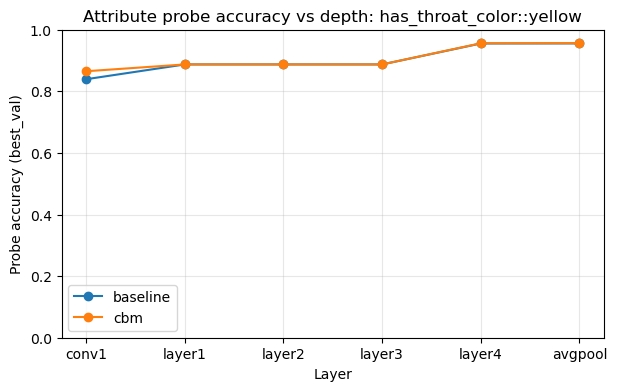

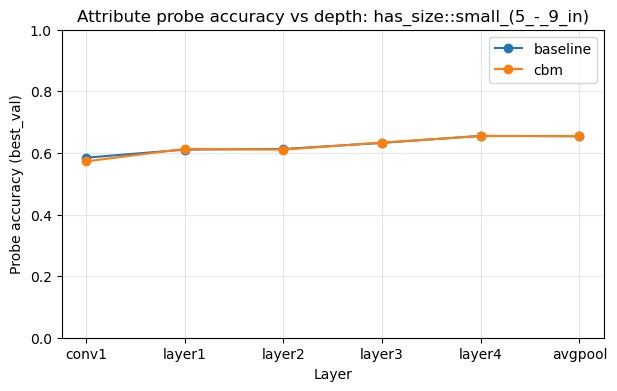

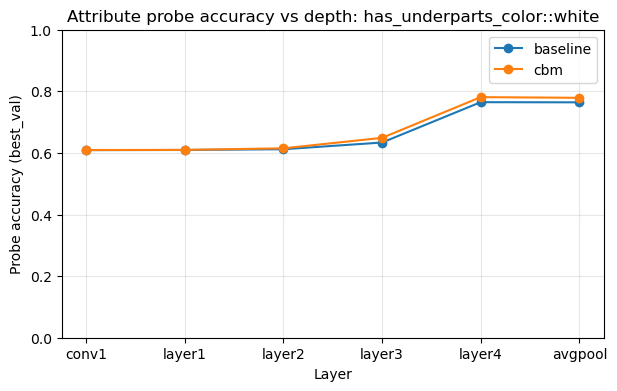

In [18]:
# CELL — Plot picked attributes (baseline vs cbm)

for a in picked:
    c0 = get_curve(df_all, "attribute", a, "baseline")
    c1 = get_curve(df_all, "attribute", a, "cbm")
    plot_curve(c0, c1, f"Attribute probe accuracy vs depth: {a}")
